<h1> Data set: Skin Cancer MNIST: HAM10000

This is an analysis of a large collection of multi-source dermatoscopic images of pigmented lesions

The final dataset consists of 10015 dermatoscopic images. 

Cases include a representative collection of all important diagnostic categories in the realm of pigmented lesions: 
- **akiec**: Actinic keratoses and intraepithelial carcinoma / Bowen's disease 
- **bcc**: Basal cell carcinoma  
- **bkl**: benign keratosis-like lesions (solar lentigines / seborrheic keratoses and lichen-planus like keratoses) 
- **df**: Dermatofibroma (df), 
- **mel**: Melanoma (mel), 
- **nv**: Melanocytic nevi (nv) and 
- **vasc**: Vascular lesions (angiomas, angiokeratomas, pyogenic granulomas and hemorrhage, vasc).

In [1]:
# Imports

import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from IPython.display import display
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, models, optimizers, metrics

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [2]:
print(os.getcwd())

/Users/leslyfahnrich/code/Cromyz/project_dermai_assist/notebooks


In [3]:
print(os.listdir("."))

['Data_treatment.ipynb', 'copy_ellie.ipynb', 'All_data_CNN_model_2.ipynb', 'All_data_CNN_filled_missing_values.ipynb', 'All_data_CNN_clean.ipynb']


<h2>1. Data upload


In [4]:
# --- BASE DIRECTORY ---
base_dir = os.getcwd()

# --- LOAD METADATA ---
metadata_path = os.path.join(base_dir, "..", "data", "HAM10000_metadata.csv")
ds = pd.read_csv(metadata_path)

# --- IMAGE FOLDERS ---
img_dir_1 = os.path.join(base_dir, "..", "data", "HAM10000_images_part_1")
img_dir_2 = os.path.join(base_dir, "..", "data", "HAM10000_images_part_2")

print("✅ Metadata loaded")


✅ Metadata loaded


In [5]:
def find_relative_image_path(image_id):
    filename = f"{image_id}.jpg"
    path1 = os.path.join(img_dir_1, filename)
    path2 = os.path.join(img_dir_2, filename)

    if os.path.exists(path1):
        return path1
    if os.path.exists(path2):
        return path2

    # If image not found, return None or log
    print(f"⚠️ Image not found: {filename}")
    return None


In [6]:
# --- Build path column ---

ds["img_path"] = ds["image_id"].apply(find_relative_image_path)
print("✅ Image path added")
print(ds.head())

✅ Image path added
     lesion_id      image_id   dx dx_type   age   sex localization  \
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp   
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp   
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp   
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp   
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear   

                                            img_path  
0  /Users/leslyfahnrich/code/Cromyz/project_derma...  
1  /Users/leslyfahnrich/code/Cromyz/project_derma...  
2  /Users/leslyfahnrich/code/Cromyz/project_derma...  
3  /Users/leslyfahnrich/code/Cromyz/project_derma...  
4  /Users/leslyfahnrich/code/Cromyz/project_derma...  


In [7]:
ds.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,img_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/Users/leslyfahnrich/code/Cromyz/project_derma...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/Users/leslyfahnrich/code/Cromyz/project_derma...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/Users/leslyfahnrich/code/Cromyz/project_derma...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/Users/leslyfahnrich/code/Cromyz/project_derma...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/Users/leslyfahnrich/code/Cromyz/project_derma...


In [8]:
# Paths to the data
#METADATA_CSV = "HAM10000_metadata.csv"
#IMAGES_DIR_1 = "HAM10000_images_part_1"
#IMAGES_DIR_2 = "HAM10000_images_part_2"

model_timings = []

# Parameters
IMG_SIZE = 224          #  input size for ResNet/DenseNet (square)
BATCH_SIZE = 32
SEED = 42
EPOCHS_SIMPLE = 15
EPOCHS_TRANSFER = 15

AUTOTUNE = tf.data.AUTOTUNE

# Fixing the seeds for some reproducibility
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Full names dictionary
FULL_DX_NAMES = {
    "akiec": "Bowen's disease",
    "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis-like lesions",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic nevi",
    "vasc": "Vascular lesions"
}

<h2> 2. Cleaning Data

In [9]:
#Loading the CSV
print("Size metadata csv :", ds.shape)


# Columns needed for the MVP
#cols_mvp = ["image_id", "lesion_id", "dx"]
#df = meta[cols_mvp].copy()

# Removing any duplicates in image_id
ds = ds.drop_duplicates(subset="image_id").reset_index(drop=True)


display(ds.head())

# Checking for missing values
print("\n Missing values :")
print(ds.isna().sum())


Size metadata csv : (10015, 8)


,lesion_id,image_id,dx,dx_type,age,sex,localization,img_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/Users/leslyfahnrich/code/Cromyz/project_derma...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/Users/leslyfahnrich/code/Cromyz/project_derma...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/Users/leslyfahnrich/code/Cromyz/project_derma...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/Users/leslyfahnrich/code/Cromyz/project_derma...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/Users/leslyfahnrich/code/Cromyz/project_derma...



 Missing values :
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
img_path         0
dtype: int64


In [10]:
# ------------------------------------------------------------------------------
# Checking missing values in age column
# ------------------------------------------------------------------------------
missing_age = ds['age'].isna().sum()
print("Number of rows with missing ages:", missing_age)

# ------------------------------------------------------------------------------
# Check how many 'unknown' in sex
# ------------------------------------------------------------------------------
num_unknown_sex = (ds['sex'] == 'unknown').sum()
print("Number of 'unknown' in sex:", num_unknown_sex)

# ------------------------------------------------------------------------------
# Check how many 'unknown' in localization
# ------------------------------------------------------------------------------
num_unknown_localization = (ds['localization'] == 'unknown').sum()
print("Number of 'unknown' in localization:", num_unknown_localization)

Number of rows with missing ages: 57
Number of 'unknown' in sex: 57
Number of 'unknown' in localization: 234


In [11]:
# ------------------------------------------------------------------------------
# Checking the rows with missing age
# ------------------------------------------------------------------------------
ds[ds['age'].isna()]

,lesion_id,image_id,dx,dx_type,age,sex,localization,img_path
968,HAM_0001186,ISIC_0033391,bkl,consensus,NaN,unknown,unknown,/Users/leslyfahnrich/code/Cromyz/project_derma...
969,HAM_0002660,ISIC_0033750,bkl,consensus,NaN,unknown,unknown,/Users/leslyfahnrich/code/Cromyz/project_derma...
970,HAM_0000372,ISIC_0033685,bkl,consensus,NaN,unknown,unknown,/Users/leslyfahnrich/code/Cromyz/project_derma...
971,HAM_0000948,ISIC_0033631,bkl,consensus,NaN,unknown,unknown,/Users/leslyfahnrich/code/Cromyz/project_derma...
972,HAM_0000983,ISIC_0033490,bkl,consensus,NaN,unknown,unknown,/Users/leslyfahnrich/code/Cromyz/project_derma...
973,HAM_0007281,ISIC_0034283,bkl,consensus,NaN,unknown,unknown,/Users/leslyfahnrich/code/Cromyz/project_derma...
974,HAM_0001561,ISIC_0032740,bkl,consensus,NaN,unknown,unknown,/Users/leslyfahnrich/code/Cromyz/project_derma...
975,HAM_0000825,ISIC_0034186,bkl,consensus,NaN,unknown,unknown,/Users/leslyfahnrich/code/Cromyz/project_derma...
977,HAM_0006074,ISIC_0034252,bkl,consensus,NaN,unknown,unknown,/Users/leslyfahnrich/code/Cromyz/project_derma...
978,HAM_0006074,ISIC_0033829,bkl,consensus,NaN,unknown,unknown,/Users/leslyfahnrich/code/Cromyz/project_derma...


One can see that there are many rows with age = NaN and at the same time location/sex = unknown.

Find rows where all three conditions happen simultaneously:
- age is NaN
- sex is "unknown"
- localization is "unknown"

In [12]:
#-------------------------------------------------------------------------------
# Filter rows where all three conditions are met
#-------------------------------------------------------------------------------

# Condition for rows to drop
condition_all_three = (
    ds['age'].isna() &
    (ds['sex'] == 'unknown') &
    (ds['localization'] == 'unknown')
)

# Number of rows to remove
removed_count = condition_all_three.sum()
print("Rows to remove (all 3 conditions):", removed_count)

# Remove them
ds_clean = ds[~condition_all_three].reset_index(drop=True)

print("\nShape after cleaning:", ds_clean.shape)

Rows to remove (all 3 conditions): 47

Shape after cleaning: (9968, 8)


In [13]:
# Missing values in age
remaining_age_nan = ds_clean['age'].isna().sum()
print("Remaining age NaN:", remaining_age_nan)

# “unknown” values in sex
remaining_sex_unknown = (ds_clean['sex'] == 'unknown').sum()
print("Remaining sex = 'unknown':", remaining_sex_unknown)

# “unknown” values in localization
remaining_loc_unknown = (ds_clean['localization'] == 'unknown').sum()
print("Remaining localization = 'unknown':", remaining_loc_unknown)


Remaining age NaN: 10
Remaining sex = 'unknown': 10
Remaining localization = 'unknown': 187


In [14]:
print("\n--- SUMMARY AFTER CLEANING ---")
print(f"Removed rows (all 3 conditions): {removed_count}")
print(f"Remaining age NaN: {remaining_age_nan}")
print(f"Remaining sex 'unknown': {remaining_sex_unknown}")
print(f"Remaining localization 'unknown': {remaining_loc_unknown}")


--- SUMMARY AFTER CLEANING ---
Removed rows (all 3 conditions): 47
Remaining age NaN: 10
Remaining sex 'unknown': 10
Remaining localization 'unknown': 187


Drop the rows where all three conditions happen simultaneously

<h2> 3. Filling Unknown/missing data

<h4>3.1. For age missing values

For skewed medical age distributions:
- mean is very sensitive to outliers
- median is robust and clinically appropriate

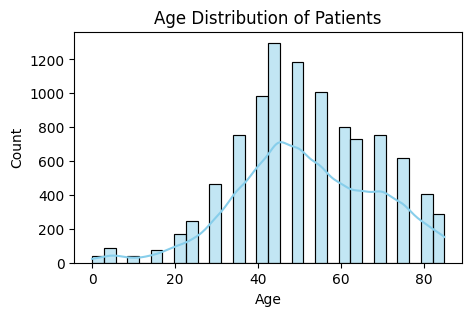

In [15]:
# Plot age distribution to check skewness
plt.figure(figsize=(5, 3))
sns.histplot(ds_clean['age'].dropna(), bins=30, kde=True, color='skyblue')
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [16]:
# ----- 1. Impute age (skewed distribution → median) -----
ds_clean["age"] = ds_clean["age"].fillna(ds_clean["age"].median())

<h4> 3.2. Handling “unknown” in categorical columns (sex and location)

Strategy: Keep “unknown” as its own category

In [17]:
# ----- 2. Replace unknown in sex with its own category -----
ds_clean["sex"] = ds_clean["sex"].replace("unknown", "unk")

In [18]:
# ----- 3. Replace unknown in localization with its own category -----
ds_clean["localization"] = ds_clean["localization"].replace("unknown", "unk")

In [19]:
# Missing values in age
remaining_age_nan2 = ds_clean['age'].isna().sum()
print("Remaining age NaN after filling:", remaining_age_nan2)

# “unknown” values in sex
remaining_sex_unknown2 = (ds_clean['sex'] == 'unknown').sum()
print("Remaining sex after filling = 'unknown':", remaining_sex_unknown2)

# “unknown” values in localization
remaining_loc_unknown2 = (ds_clean['localization'] == 'unknown').sum()
print("Remaining localization after filling = 'unknown':", remaining_loc_unknown2)

Remaining age NaN after filling: 0
Remaining sex after filling = 'unknown': 0
Remaining localization after filling = 'unknown': 0


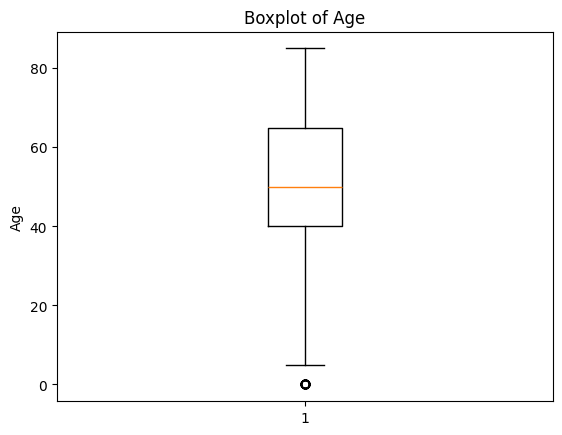

In [20]:
# ------------------------------------------------------------------------------
# Checking outliers
# ------------------------------------------------------------------------------
plt.boxplot(ds_clean['age'].dropna())
plt.title("Boxplot of Age")
plt.ylabel("Age")
plt.show()

<h2>4. Label encoding of the diagnostic categories (dx)

In [21]:
# ------------------------------------------------------------------------------
# Label encoding
# ------------------------------------------------------------------------------
class_names = sorted(ds_clean["dx"].unique())
class_to_index = {name: idx for idx, name in enumerate(class_names)}
index_to_class = {idx: name for name, idx in class_to_index.items()}

ds_clean["label"] = ds_clean["dx"].map(class_to_index)

num_classes = len(class_names)
print("Classes :", class_names)
print("Class names:", num_classes)

display(ds_clean.head())


Classes : ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Class names: 7


,lesion_id,image_id,dx,dx_type,age,sex,localization,img_path,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/Users/leslyfahnrich/code/Cromyz/project_derma...,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/Users/leslyfahnrich/code/Cromyz/project_derma...,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/Users/leslyfahnrich/code/Cromyz/project_derma...,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/Users/leslyfahnrich/code/Cromyz/project_derma...,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/Users/leslyfahnrich/code/Cromyz/project_derma...,2


In [22]:
print(ds_clean.shape)
print(ds_clean["lesion_id"].isna().sum())
print(ds_clean["lesion_id"].nunique())
print(ds_clean["lesion_id"].head())

(9968, 9)
0
7424
0    HAM_0000118
1    HAM_0000118
2    HAM_0002730
3    HAM_0002730
4    HAM_0001466
Name: lesion_id, dtype: object


In [23]:
# ------------------------------------------------------------------------------
# Split at the lesion_id level (to prevent data leakage)
# ------------------------------------------------------------------------------

lesion_df = ds_clean.groupby("lesion_id")["dx"].first().reset_index()

train_lesions, temp_lesions = train_test_split(
    lesion_df,
    test_size=0.3,
    random_state=SEED,
    stratify=lesion_df["dx"],
)

val_lesions, test_lesions = train_test_split(
    temp_lesions,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_lesions["dx"],
)

train_ids = set(train_lesions["lesion_id"])
val_ids = set(val_lesions["lesion_id"])
test_ids = set(test_lesions["lesion_id"])

def split_df(ds, train_ids, val_ids, test_ids):
    train_df = ds[ds["lesion_id"].isin(train_ids)].copy()
    val_df = ds[ds["lesion_id"].isin(val_ids)].copy()
    test_df = ds[ds["lesion_id"].isin(test_ids)].copy()
    return train_df, val_df, test_df

train_df, val_df, test_df = split_df(ds_clean, train_ids, val_ids, test_ids)

print("Train size :", train_df.shape)
print("Size val   :", val_df.shape)
print("Test size  :", test_df.shape)

print("\nClass distribution (train) :")
display(train_df["dx"].value_counts())


Train size : (6963, 9)
Size val   : (1481, 9)
Test size  : (1524, 9)

Class distribution (train) :


dx
nv       4685
mel       779
bkl       738
bcc       361
akiec     224
vasc       96
df         80
Name: count, dtype: int64

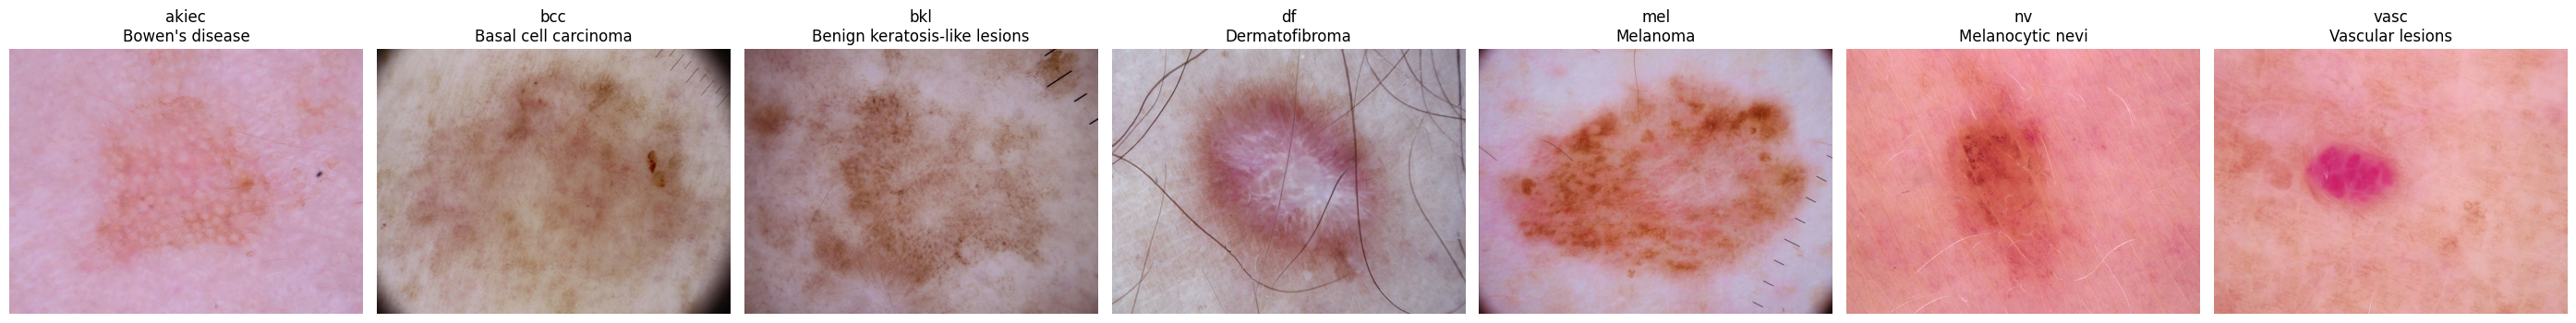

In [24]:
# ------------------------------------------------------------------------------
# Display one image per lesion type
# ------------------------------------------------------------------------------


def show_one_image_per_class(df, class_names, seed=SEED):
    plt.figure(figsize=(4 * len(class_names), 4))

    for i, cls in enumerate(class_names):
        sample = df[df["dx"] == cls].sample(1, random_state=seed)
        img_path = sample["img_path"].values[0]
        img = plt.imread(img_path)

        full_name = FULL_DX_NAMES.get(cls, "Unknown class")

        ax = plt.subplot(1, len(class_names), i + 1)
        plt.imshow(img)

        # Show abbreviation and full name
        plt.title(f"{cls}\n{full_name}")

        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Call the function
show_one_image_per_class(ds_clean, class_names)

In [25]:
# ------------------------------------------------------------------------------
# Creating the TensorFlow datasets (tf.data) VERSION 1
# ------------------------------------------------------------------------------

def df_to_dataset(df_subset, shuffle=True):
    paths = df_subset["img_path"].values
    labels = df_subset["label"].values
    labels = tf.one_hot(labels, depth=num_classes)  # Convert to one-hot

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def load_image(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_jpeg(image, channels=3)
        image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
        image = tf.cast(image, tf.float32) / 255.0
        return image, label

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(df_subset), seed=SEED)

    return ds




train_ds = df_to_dataset(train_df, shuffle=True)
val_ds = df_to_dataset(val_df, shuffle=False)
test_ds = df_to_dataset(test_df, shuffle=False)

train_ds


<_ShuffleDataset element_spec=(TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(7,), dtype=tf.float32, name=None))>

<h2> 5. Preparation of dataset

1. Data augmentation

2. Define all helper functions
	•	oversampling
	•	df_to_dataset
	•	prepare_train / prepare_eval

3. Oversample your TRAIN dataframe

4. Convert CSV → tf.data (raw datasets)

5. Apply augmentation/batching/prefetching

In [26]:
# ===============================================================
# 1. DATA AUGMENTATION LAYER
# ===============================================================

data_augmentation = keras.Sequential(
    [
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.RandomContrast(0.25),
        layers.RandomBrightness(0.25),
        layers.RandomTranslation(0.05, 0.05),  # very small shift
        layers.RandomFlip("horizontal"),
    ],
    name="data_augmentation",
)

# ===============================================================
# 2. HELPER FUNCTIONS
# ===============================================================

# ------------------------------------------------------------------------------
# 2.1. Oversampling to balance classes (for training only)
# ------------------------------------------------------------------------------

def oversample_dataframe(df, label_col="dx", seed=SEED):
    class_counts = df[label_col].value_counts()
    max_count = class_counts.max()

    oversampled_dfs = [
        df_group.sample(max_count, replace=True, random_state=seed)
        for _, df_group in df.groupby(label_col)
    ]

    balanced_df = (
        pd.concat(oversampled_dfs)
        .sample(frac=1.0, random_state=seed)
        .reset_index(drop=True)
    )

    return balanced_df


In [27]:
# ---------------------------------------------------------------
# 2.2 Convert dataframe → tf.data.Dataset (NO batching here!)
# ---------------------------------------------------------------
# without batching to avoid problems in the optimized model

def df_to_dataset(df_subset, shuffle=True):
    paths = df_subset["img_path"].values
    labels = df_subset["label"].values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def load_image(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_jpeg(image, channels=3)
        image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
        image = tf.cast(image, tf.float32) / 255.0
        return image, label

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(df_subset), seed=SEED)

    return ds


# ---------------------------------------------------------------
# 2.3 Apply augmentation + batch/prefetch
# ---------------------------------------------------------------
def prepare_train(ds):
    ds = ds.map(
        lambda x, y: (data_augmentation(x), y),
        num_parallel_calls=AUTOTUNE
    )
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


def prepare_eval(ds):
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


In [28]:
# ===============================================================
# 3. OVERSAMPLE ONLY THE TRAINING DATAFRAME
# ===============================================================

balanced_train_df = oversample_dataframe(train_df, label_col="dx")

print("📊 Rebalanced class distribution:")
print(balanced_train_df["dx"].value_counts())


📊 Rebalanced class distribution:
dx
bcc      4685
akiec    4685
mel      4685
bkl      4685
nv       4685
df       4685
vasc     4685
Name: count, dtype: int64


In [29]:
# ===============================================================
# 4. CONVERT DATAFRAMES → RAW TF.DATA DATASETS
# ===============================================================
raw_train_ds = df_to_dataset(balanced_train_df, shuffle=True)
raw_val_ds   = df_to_dataset(val_df, shuffle=False)
raw_test_ds  = df_to_dataset(test_df, shuffle=False)

In [30]:
# ===============================================================
# 5. FINAL DATASETS (batch & prefetch only)
# ===============================================================

train_ds = raw_train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds   = raw_val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds  = raw_test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

<h2> 5. Create a plotting function

In [31]:
#-------------------------------------------------------------------------------
# Utility function for plotting curves from history
#-------------------------------------------------------------------------------

def plot_history(history, title_suffix="", save_path=None):
    """
    Plots training metrics from a Keras History object.
    Works with any combination of metrics (loss, accuracy, precision, recall, AUC).

    Parameters:
    - history: keras.callbacks.History returned by model.fit()
    - title_suffix: string added to plot titles
    - save_path: optional path to save the figure (e.g. 'training_plot.png')
    """

    if not hasattr(history, "history") or len(history.history) == 0:
        print("⚠️ Empty History object — nothing to plot.")
        return

    hist = history.history
    metrics = list(hist.keys())

    # ---- Identify available metric groups ----
    def find_metrics(substr):
        return [m for m in metrics if substr in m.lower()]

    loss_keys      = find_metrics("loss")
    acc_keys       = find_metrics("acc") + find_metrics("accuracy")
    precision_keys = find_metrics("precision")
    recall_keys    = find_metrics("recall")
    auc_keys       = find_metrics("auc")

    epochs = range(1, len(hist[loss_keys[0]]) + 1)

    # ---- Create figure ----
    plt.figure(figsize=(18, 10))

    groups = [
        ("Loss", loss_keys),
        ("Accuracy", acc_keys),
        ("Precision", precision_keys),
        ("Recall", recall_keys),
        ("AUC", auc_keys),
    ]

    plot_idx = 1
    color_map = {"train": "tab:blue", "val": "tab:orange"}

    # ---- Plot each metric group ----
    for title, keys in groups:
        if not keys:
            continue

        plt.subplot(2, 3, plot_idx)

        for key in keys:
            color = color_map["val"] if key.startswith("val_") else color_map["train"]
            plt.plot(epochs, hist[key], label=key, color=color)

        plt.title(f"{title} {title_suffix}")
        plt.xlabel("Epoch")
        plt.ylabel(title)
        plt.legend()
        plt.grid(True)

        plot_idx += 1

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)
        print(f"📁 Plot saved to: {save_path}")

    plt.show()

    # ---- Interpretation guide ----
    print("\n📘 **How to interpret these metrics for skin lesion classification:**\n")
    print("• **Loss curves**: Training ↓ but Validation ↑ = overfitting.")
    print("• **Accuracy**: Not always meaningful with imbalanced classes.")
    print("• **Precision**: High precision = few false positives.")
    print("• **Recall (CRITICAL)**: High recall = malignant lesions detected, low false negatives.")
    print("• **AUC**: Measures separability; >0.90 = strong clinical classifier.")

<h2> 6. Create a Time Tracking Callback

In [32]:
import time
from tensorflow.keras.callbacks import Callback
class TimeHistory(Callback):

    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        epoch_time = time.time() - self.epoch_start
        self.epoch_times.append(epoch_time)

    @property
    def total_time(self):
        return time.time() - self.start_time

<h2> 7. Models

<h4> Model 2

Model 2 is designed for better generalization, better convergence, and more reliable evaluation metrics.

1. Replace ReLU with ReLU + He initialization.
2. Add Dropout between convolution blocks
3. Increase dense layer to 256 units
4. Use a slightly higher dropout (0.5 → 0.4 or 0.3 depending on dataset)
5. Add learning rate warm-up 


Key metrics for skin lesion classification
- **Recall** / Sensitivity is usually the highest priority, because missing a melanoma is dangerous.
- Precision is secondary — you don’t want too many false positives, but false negatives are worse.
- Accuracy alone is misleading if most lesions are benign.
- AUC is useful to compare models independent of thresholds.
- F1-score is nice to summarize precision and recall in one number, especially for imbalanced classes.

In [33]:
from tensorflow import keras
from tensorflow.keras import layers, regularizers

def build_cnn_improved(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=num_classes,
    use_augmentation=False
):
    """
    Improved CNN for skin lesion classification.

    Key improvements over simple CNN:
    - Data augmentation inside model to avoid dataset pipeline issues
    - BatchNormalization for faster and stable training
    - L2 regularization to prevent overfitting
    - Dropout to reduce overfitting
    - AdamW optimizer for better generalization
    - Metrics suitable for medical classification:
        accuracy, AUC, precision, recall
    """

    inputs = keras.Input(shape=input_shape)
    x = inputs

    # -------------------------------------------------------
    # Optional Data Augmentation block (applied inside model)
    # -------------------------------------------------------
    if use_augmentation:
        x = keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.15),
            layers.RandomZoom(0.15),
            layers.RandomContrast(0.15),
            layers.RandomBrightness(0.15)
        ], name="data_augmentation")(x)

    # -------------------------------------------------------
    # Block 1: Conv → BatchNorm → MaxPool
    # -------------------------------------------------------
    x = layers.Conv2D(
        32, 3, padding="same", activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # -------------------------------------------------------
    # Block 2
    # -------------------------------------------------------
    x = layers.Conv2D(
        64, 3, padding="same", activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # -------------------------------------------------------
    # Block 3
    # -------------------------------------------------------
    x = layers.Conv2D(
        128, 3, padding="same", activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # -------------------------------------------------------
    # Global pooling + Dense head
    # -------------------------------------------------------
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    # Output layer
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    # Build model
    model = keras.Model(inputs, outputs, name="cnn_improved_augmented")

    # Compile with metrics relevant for medical classification

    model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],   # ← ONLY THIS!
)





    return model


Model: "cnn_improved_augmented"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,559 (435.78 KB)

 Trainable params: 111,111 (434.03 KB)

 Non-trainable params: 448 (1.75 KB)

...

1025/1025 ━━━━━━━━━━━━━━━━━━━━ 616s 575ms/step - accuracy: 0.2529 - loss: 1.8003 - val_accuracy: 0.4517 - val_loss: 1.5205 - learning_rate: 9.0000e-06
Epoch 26/50


2025-11-17 18:42:24.291679: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:9: Filling up shuffle buffer (this may take a while): 13577 of 32795
2025-11-17 18:42:39.473345: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


1025/1025 ━━━━━━━━━━━━━━━━━━━━ 640s 599ms/step - accuracy: 0.2485 - loss: 1.8028 - val_accuracy: 0.4713 - val_loss: 1.4801 - learning_rate: 2.7000e-06
Epoch 27/50


2025-11-17 18:53:04.390532: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:9: Filling up shuffle buffer (this may take a while): 12841 of 32795
2025-11-17 18:53:14.390776: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:9: Filling up shuffle buffer (this may take a while): 24539 of 32795
2025-11-17 18:53:21.553722: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


1025/1025 ━━━━━━━━━━━━━━━━━━━━ 687s 643ms/step - accuracy: 0.2488 - loss: 1.8061 - val_accuracy: 0.4740 - val_loss: 1.4601 - learning_rate: 2.7000e-06


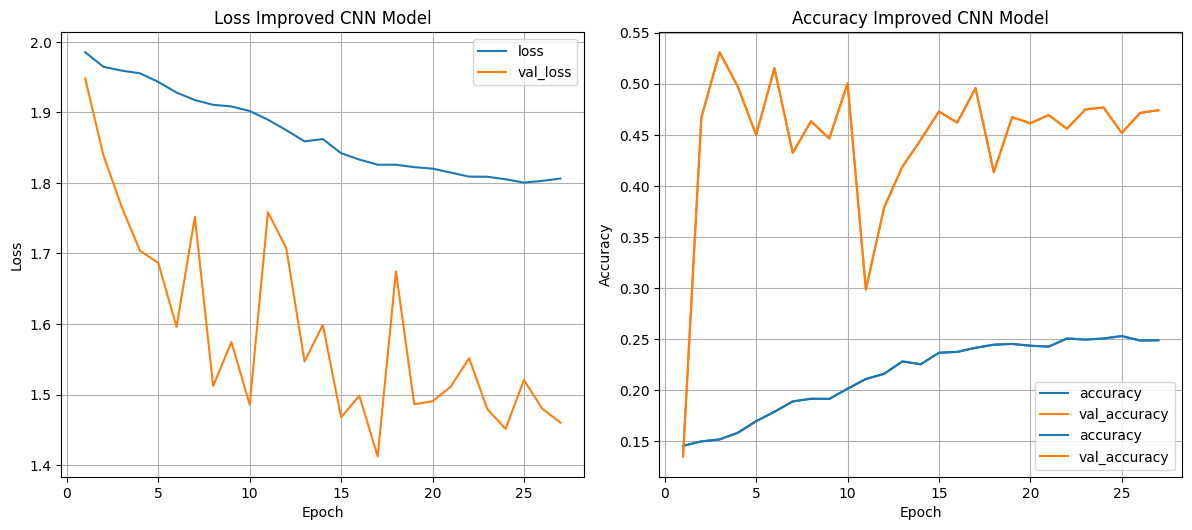


📘 **How to interpret these metrics for skin lesion classification:**

• **Loss curves**: Training ↓ but Validation ↑ = overfitting.
• **Accuracy**: Not always meaningful with imbalanced classes.
• **Precision**: High precision = few false positives.
• **Recall (CRITICAL)**: High recall = malignant lesions detected, low false negatives.
• **AUC**: Measures separability; >0.90 = strong clinical classifier.


In [34]:

# 1. Build model
model = build_cnn_improved(use_augmentation=True)
model.summary()

# 2. Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=4
    )
]

# 3. Train model

time_callback = TimeHistory()

history_2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks + [time_callback]
)
model_timings.append({
    "model_name": "Improved CNN",
    "total_time_sec": time_callback.total_time,
    "total_time_min": time_callback.total_time / 60,
    "avg_epoch_time_sec": sum(time_callback.epoch_times) / len(time_callback.epoch_times),
    "epochs_run": len(time_callback.epoch_times)
})
# 4. Plot results
plot_history(history_2, "Improved CNN Model")

<h4> Model 3

This model includes: 

✔ 4 Conv blocks

✔ Filters: 32 → 64 → 128 → 256

✔ BatchNorm after each Conv

✔ MaxPooling2D after each block

✔ Dense(512) + Dropout(0.5) head

✔ Keep your L2 regularization + AdamW + augmentation 

- This model considerates: ModelCheckpoint, ReduceLROnPlateau, and EarlyStopping work together perfectly.

In [38]:
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

def build_cnn_4blocks_callbacks(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=num_classes,
    use_augmentation=False,
    model_path="best_model.keras"
):
    """
    Improved CNN with SAME BLOCKS as Sequential model plus:
    - Augmentation (optional)
    - L2 regularization
    - 4 Conv blocks: 32 → 64 → 128 → 256
    - BatchNorm + MaxPool per block
    - Dense 512 + Dropout(0.5)
    - AdamW optimizer
    - ModelCheckpoint
    - ReduceLROnPlateau
    - EarlyStopping
    """

    # -----------------------
    # Input
    # -----------------------
    inputs = keras.Input(shape=input_shape)
    x = inputs

    # -----------------------
    # Augmentation (optional)
    # -----------------------
    if use_augmentation:
        x = keras.Sequential([
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.15),
            layers.RandomZoom(0.15),
            layers.RandomContrast(0.15),
            layers.RandomBrightness(0.15),
        ], name="augmentation")(x)

    # -----------------------
    # BLOCK 1 — 32 filters
    # -----------------------
    x = layers.Conv2D(32, 3, padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # -----------------------
    # BLOCK 2 — 64 filters
    # -----------------------
    x = layers.Conv2D(64, 3, padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # -----------------------
    # BLOCK 3 — 128 filters
    # -----------------------
    x = layers.Conv2D(128, 3, padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # -----------------------
    # BLOCK 4 — 256 filters
    # -----------------------
    x = layers.Conv2D(256, 3, padding="same", activation="relu",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # -----------------------
    # Dense Head
    # -----------------------
    x = layers.Flatten()(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="cnn_improved_matching")

    # -----------------------
    # Compile
    # -----------------------
    model.compile(
        optimizer=keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # -----------------------
    # Callbacks
    # -----------------------
    modelCheckpoint = callbacks.ModelCheckpoint(
        model_path,
        monitor="val_loss",
        verbose=0,
        save_best_only=True
    )

    LRreducer = callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.1,
        patience=3,
        verbose=1,
        min_lr=0
    )

    earlyStop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        verbose=1,
        restore_best_weights=True
    )

    return model, [modelCheckpoint, LRreducer, earlyStop]


In [39]:
model, cb = build_cnn_4blocks_callbacks()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=cb
)

Epoch 1/50


2025-11-17 20:58:46.857570: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:9: Filling up shuffle buffer (this may take a while): 15313 of 32795
2025-11-17 20:58:56.860700: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:9: Filling up shuffle buffer (this may take a while): 29426 of 32795
2025-11-17 20:58:59.599700: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


1025/1025 ━━━━━━━━━━━━━━━━━━━━ 840s 794ms/step - accuracy: 0.7310 - loss: 0.8524 - val_accuracy: 0.6833 - val_loss: 0.9657 - learning_rate: 1.0000e-04
Epoch 2/50


2025-11-17 21:12:45.617442: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:9: Filling up shuffle buffer (this may take a while): 12797 of 32795
2025-11-17 21:13:02.003013: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


1025/1025 ━━━━━━━━━━━━━━━━━━━━ 848s 799ms/step - accuracy: 0.8871 - loss: 0.3431 - val_accuracy: 0.6968 - val_loss: 0.9896 - learning_rate: 1.0000e-04
Epoch 3/50


...

1025/1025 ━━━━━━━━━━━━━━━━━━━━ 863s 810ms/step - accuracy: 0.9910 - loss: 0.0591 - val_accuracy: 0.7664 - val_loss: 1.1272 - learning_rate: 1.0000e-05
Epoch 7/50


2025-11-17 22:23:55.827767: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:9: Filling up shuffle buffer (this may take a while): 13488 of 32795
2025-11-17 22:24:05.829037: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:9: Filling up shuffle buffer (this may take a while): 25900 of 32795
2025-11-17 22:24:11.805234: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


1025/1025 ━━━━━━━━━━━━━━━━━━━━ 0s 774ms/step - accuracy: 0.9936 - loss: 0.0529
Epoch 7: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-07.
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 830s 782ms/step - accuracy: 0.9940 - loss: 0.0517 - val_accuracy: 0.7664 - val_loss: 1.1884 - learning_rate: 1.0000e-05
Epoch 8/50


2025-11-17 22:37:45.870780: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:9: Filling up shuffle buffer (this may take a while): 13736 of 32795
2025-11-17 22:37:55.869948: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:9: Filling up shuffle buffer (this may take a while): 26448 of 32795
2025-11-17 22:38:01.194322: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


1025/1025 ━━━━━━━━━━━━━━━━━━━━ 831s 784ms/step - accuracy: 0.9946 - loss: 0.0476 - val_accuracy: 0.7718 - val_loss: 1.1794 - learning_rate: 1.0000e-06
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 1.


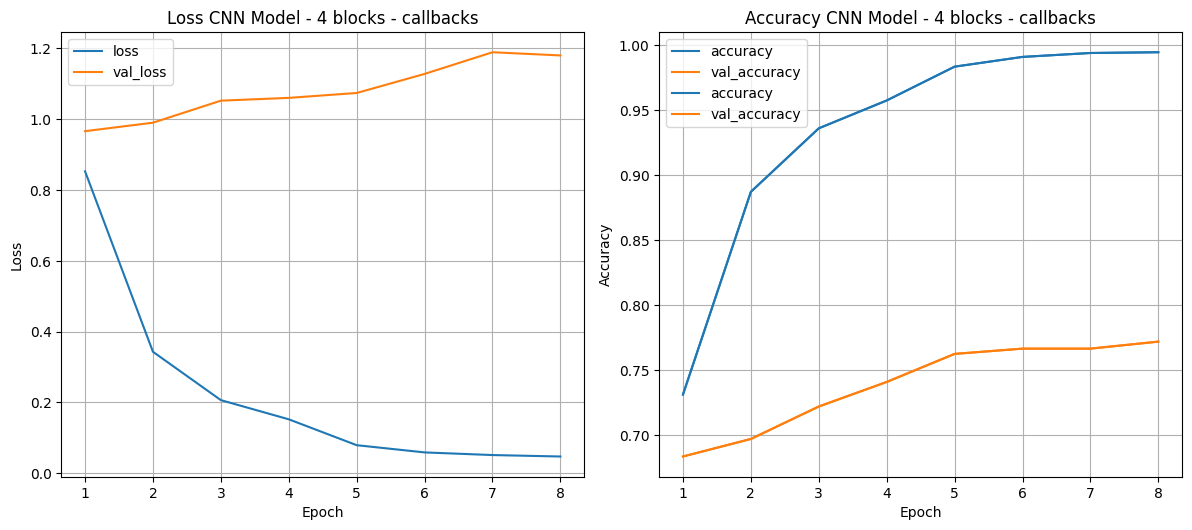


📘 **How to interpret these metrics for skin lesion classification:**

• **Loss curves**: Training ↓ but Validation ↑ = overfitting.
• **Accuracy**: Not always meaningful with imbalanced classes.
• **Precision**: High precision = few false positives.
• **Recall (CRITICAL)**: High recall = malignant lesions detected, low false negatives.
• **AUC**: Measures separability; >0.90 = strong clinical classifier.


In [41]:
plot_history(history, "CNN Model - 4 blocks - callbacks")

In [40]:
# To get a dataframe witht he name of the model and the total and avg echo time

df_timings = pd.DataFrame(model_timings)
df_timings

,model_name,total_time_sec,total_time_min,avg_epoch_time_sec,epochs_run
0,Improved CNN,17062.47567,284.374595,631.940756,27


input_layer_6
Nombre total de couches DenseNet : 427
Couches gelées jusqu'à l'indice : 298
Epoch 1/10
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 205s 116ms/step - accuracy: 0.5851 - loss: 1.1757 - val_accuracy: 0.6299 - val_loss: 1.0117
Epoch 2/10
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 166s 110ms/step - accuracy: 0.7573 - loss: 0.6355 - val_accuracy: 0.6717 - val_loss: 0.9088
Epoch 3/10
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 166s 110ms/step - accuracy: 0.8152 - loss: 0.4920 - val_accuracy: 0.6841 - val_loss: 0.9107
Epoch 4/10
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 166s 110ms/step - accuracy: 0.8606 - loss: 0.3878 - val_accuracy: 0.6991 - val_loss: 0.8778
Epoch 5/10
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 166s 110ms/step - accuracy: 0.8863 - loss: 0.3142 - val_accuracy: 0.7010 - val_loss: 0.9012
Epoch 6/10
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 166s 110ms/step - accuracy: 0.9071 - loss: 0.2598 - val_accuracy: 0.7004 - val_loss: 0.9424
Epoch 7/10
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 166s 110ms/step - accuracy: 0.9231 - loss: 0.2175 - val_accurac

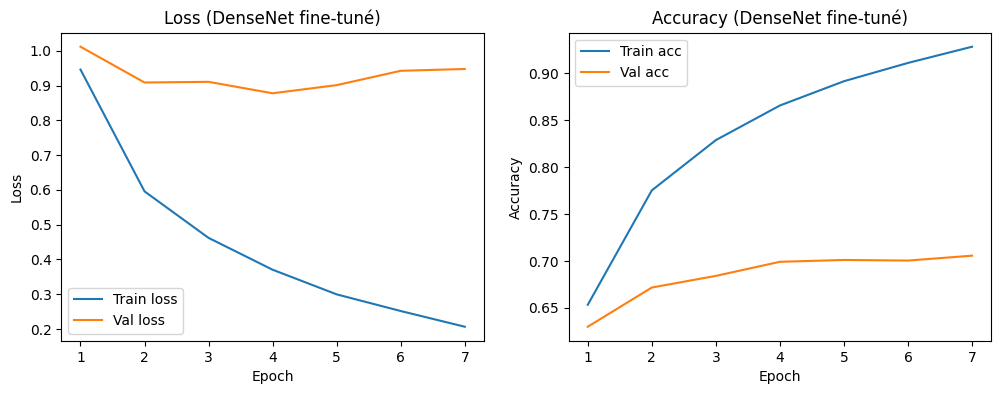

47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.7336 - loss: 0.7833
Test accuracy après fine-tuning : 0.7190412878990173


In [ ]:
# Fine-tuning: Unfreezing a portion of the DenseNet layers

# 1) Retrieve the DenseNet backbone in the complete model
# (its default name is usually "densenet121")
for layer in densenet_model.layers:
    print(layer.name)
    break

# Model summary (optional)

base_model = densenet_model.get_layer("densenet121")  # nom du backbone
base_model.trainable = True

#2) Only about 30% of the deepest layers thaw.
fine_tune_at = int(len(base_model.layers) * 0.7)
for i, layer in enumerate(base_model.layers):
    if i < fine_tune_at:
        layer.trainable = False

print("Total number of DenseNet couches :", len(base_model.layers))
print("Frozen diapers up to the index :", fine_tune_at)

# 3) Recompile with a smaller learning rate
densenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

#4) Early stopping to avoid overtraining
early_stop_ft = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# 5) Fine-tuning
history_ft = densenet_model.fit(
    balanced_train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop_ft]
)

plot_history(history_ft, "(DenseNet fine-tuné)")

#6) Final evaluation on the test set
test_loss, test_acc = densenet_model.evaluate(test_ds)
print("Test accuracy après fine-tuning :", test_acc)


In [ ]:
#MODEL_PATH = "skin_lesion_densenet_finetuned.h5"
#densenet_model.save(MODEL_PATH)
#print("Modèle sauvegardé sous :", MODEL_PATH)


Modèle sauvegardé sous : skin_lesion_densenet_finetuned.h5


In [ ]:
# Étape 14 : prédiction sur une image choisie

#def load_and_preprocess_image(path):
#    image = tf.io.read_file(path)
#    image = tf.image.decode_jpeg(image, channels=3)
#    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
#    image = tf.cast(image, tf.float32) / 255.0
#    image = tf.expand_dims(image, axis=0)
#    return image

#def predict_image(model, img_path, class_names):
#    img = load_and_preprocess_image(img_path)
#    preds = model.predict(img)
#    pred_index = np.argmax(preds[0])
#    pred_class = class_names[pred_index]
#    print("Lésion prédite :", pred_class)

# Exemple d'utilisation (adapter le chemin !) :
#test_image_path = "HAM10000_images_part_1/ISIC_0028393.jpg"  # à adapter
#predict_image(densenet_model, test_image_path, class_names)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Lésion prédite : akiec


In [ ]:
# Sauvegarde du modèle final au format .keras

#FINAL_MODEL_PATH = "skin_lesion_densenet_finetuned.keras"
#densenet_model.save(FINAL_MODEL_PATH)
#print("Modèle sauvegardé sous :", FINAL_MODEL_PATH)


Modèle sauvegardé sous : skin_lesion_densenet_finetuned.keras
